# models

In [1]:
# basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# train test split
from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# linear regression
from sklearn.linear_model import LinearRegression

# XGBOOST
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# xgboost regressor
from xgboost import XGBRegressor


# shap
import shap

# metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


# graphics
import seaborn as sns
from sklearn.tree import plot_tree


pd.set_option('display.float_format', '{:.2f}'.format)

c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# read data

df = pd.read_csv("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/04_clusters/conversation_features_clusters.pkl")


#### train test split

In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [4]:
# features selection v02
  
FEATURES_SELECTED_v02 = {
    'cat': [
        "task_type",
        "topic_label",
        "prompt_style"        
        ],
    'num': [
        "first_prompt_tokens",                
        "orthographic_error_rate",
        "question_count"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        "long_context_prompt",
        "has_question"
        ]
}

<Axes: >

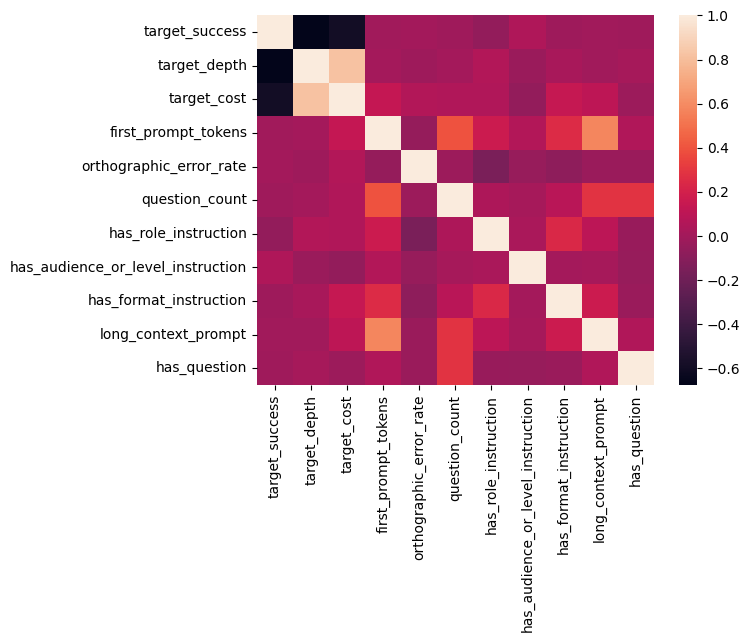

In [5]:
# correlations
temp_cols = [
    "target_success",
    "target_depth",
    "target_cost"
] + FEATURES_SELECTED_v02["num"] + FEATURES_SELECTED_v02["bin"]


sns.heatmap(df[temp_cols].corr())

In [6]:
# no NaNs 

# target_sucess

### Baseline model for "target_success" with RandomForestClassifier

In [17]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_rfc_01 = RandomForestClassifier(random_state=42) 

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfc_01)
])

# fit model
pipeline.fit(df_train[features_cols], df_train["target_success"])     # weighting doesn´t change metrics

# predict test
target_test_success_pred = pipeline.predict(df_test[features_cols])
target_test_success_proba = pipeline.predict_proba(df_test[features_cols])[:, 1]

# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.6989912447658927
f1_score: 0.3375916230366492
ROC AUC: 0.6263351607838159


In [18]:
model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

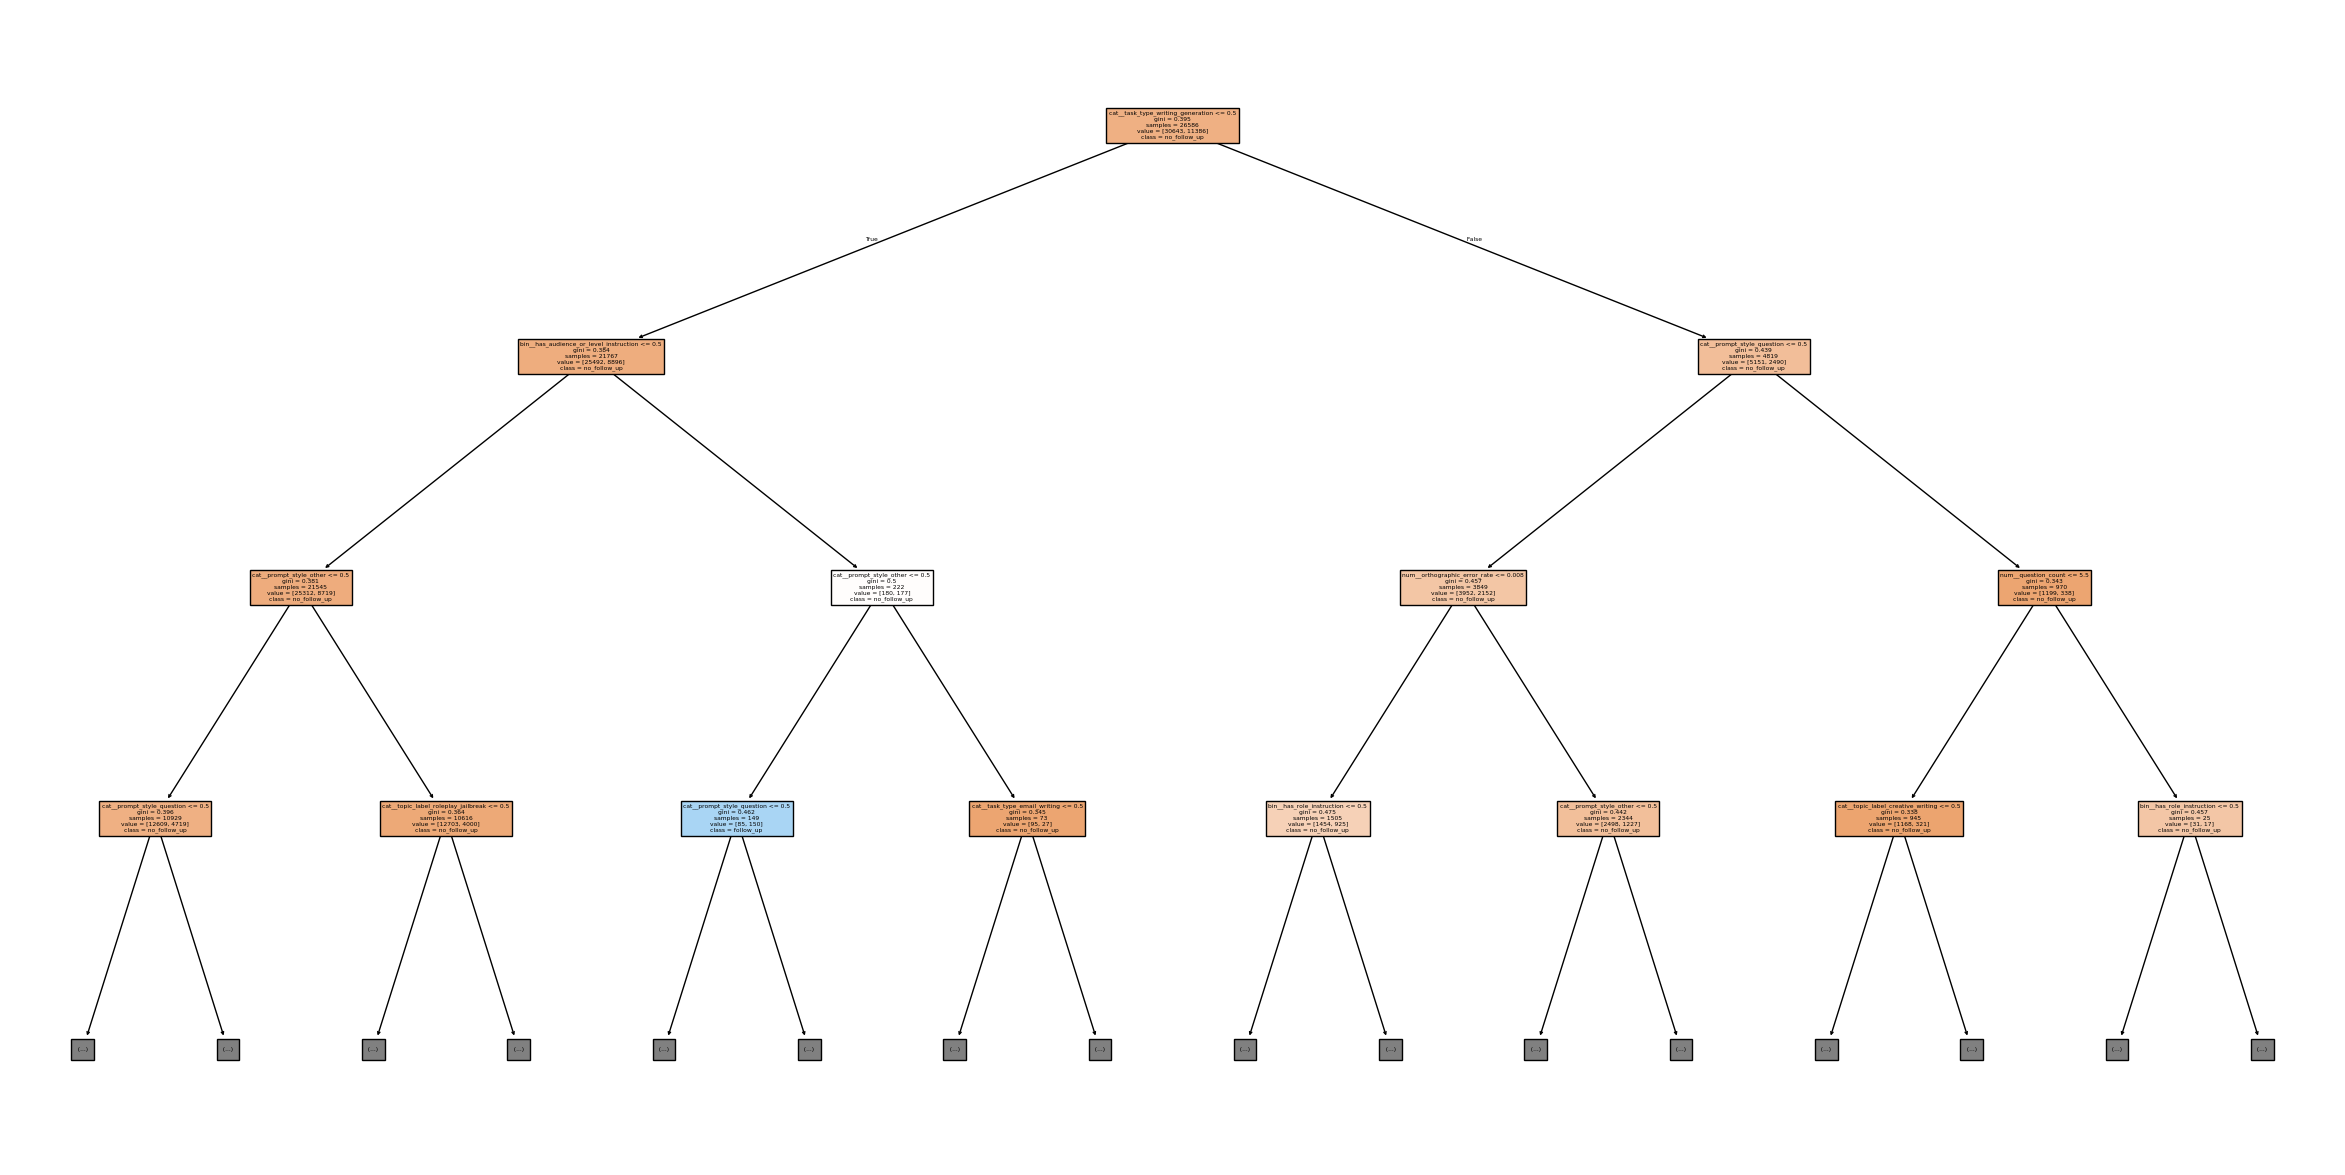

In [19]:
tree = model.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["no_follow_up", "follow_up"],
    filled=True,
    max_depth=3
)

plt.show()

In [20]:
importances = model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

,feature,importance
0,num__first_prompt_tokens,0.50
1,num__orthographic_error_rate,0.34
2,num__question_count,0.02
5,bin__has_format_instruction,0.02
3,bin__has_role_instruction,0.01
20,cat__topic_label_generic_assistance,0.01
9,cat__task_type_coding,0.01
25,cat__prompt_style_instruction,0.01
12,cat__task_type_general_assistance,0.01
16,cat__task_type_writing_generation,0.01


# target_costs

### Baseline model for "target_cost" with RandomForestRegressor

In [21]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_rfr_01 = RandomForestRegressor(random_state=42)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfr_01)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_cost"]
)

# predict test
target_test_cost_pred = pipeline.predict(df_test[features_cols])

# metrics
print("R2 Score:", r2_score(df_test["target_cost"], target_test_cost_pred))

R2 Score: 0.15162737975468277


In [12]:
model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

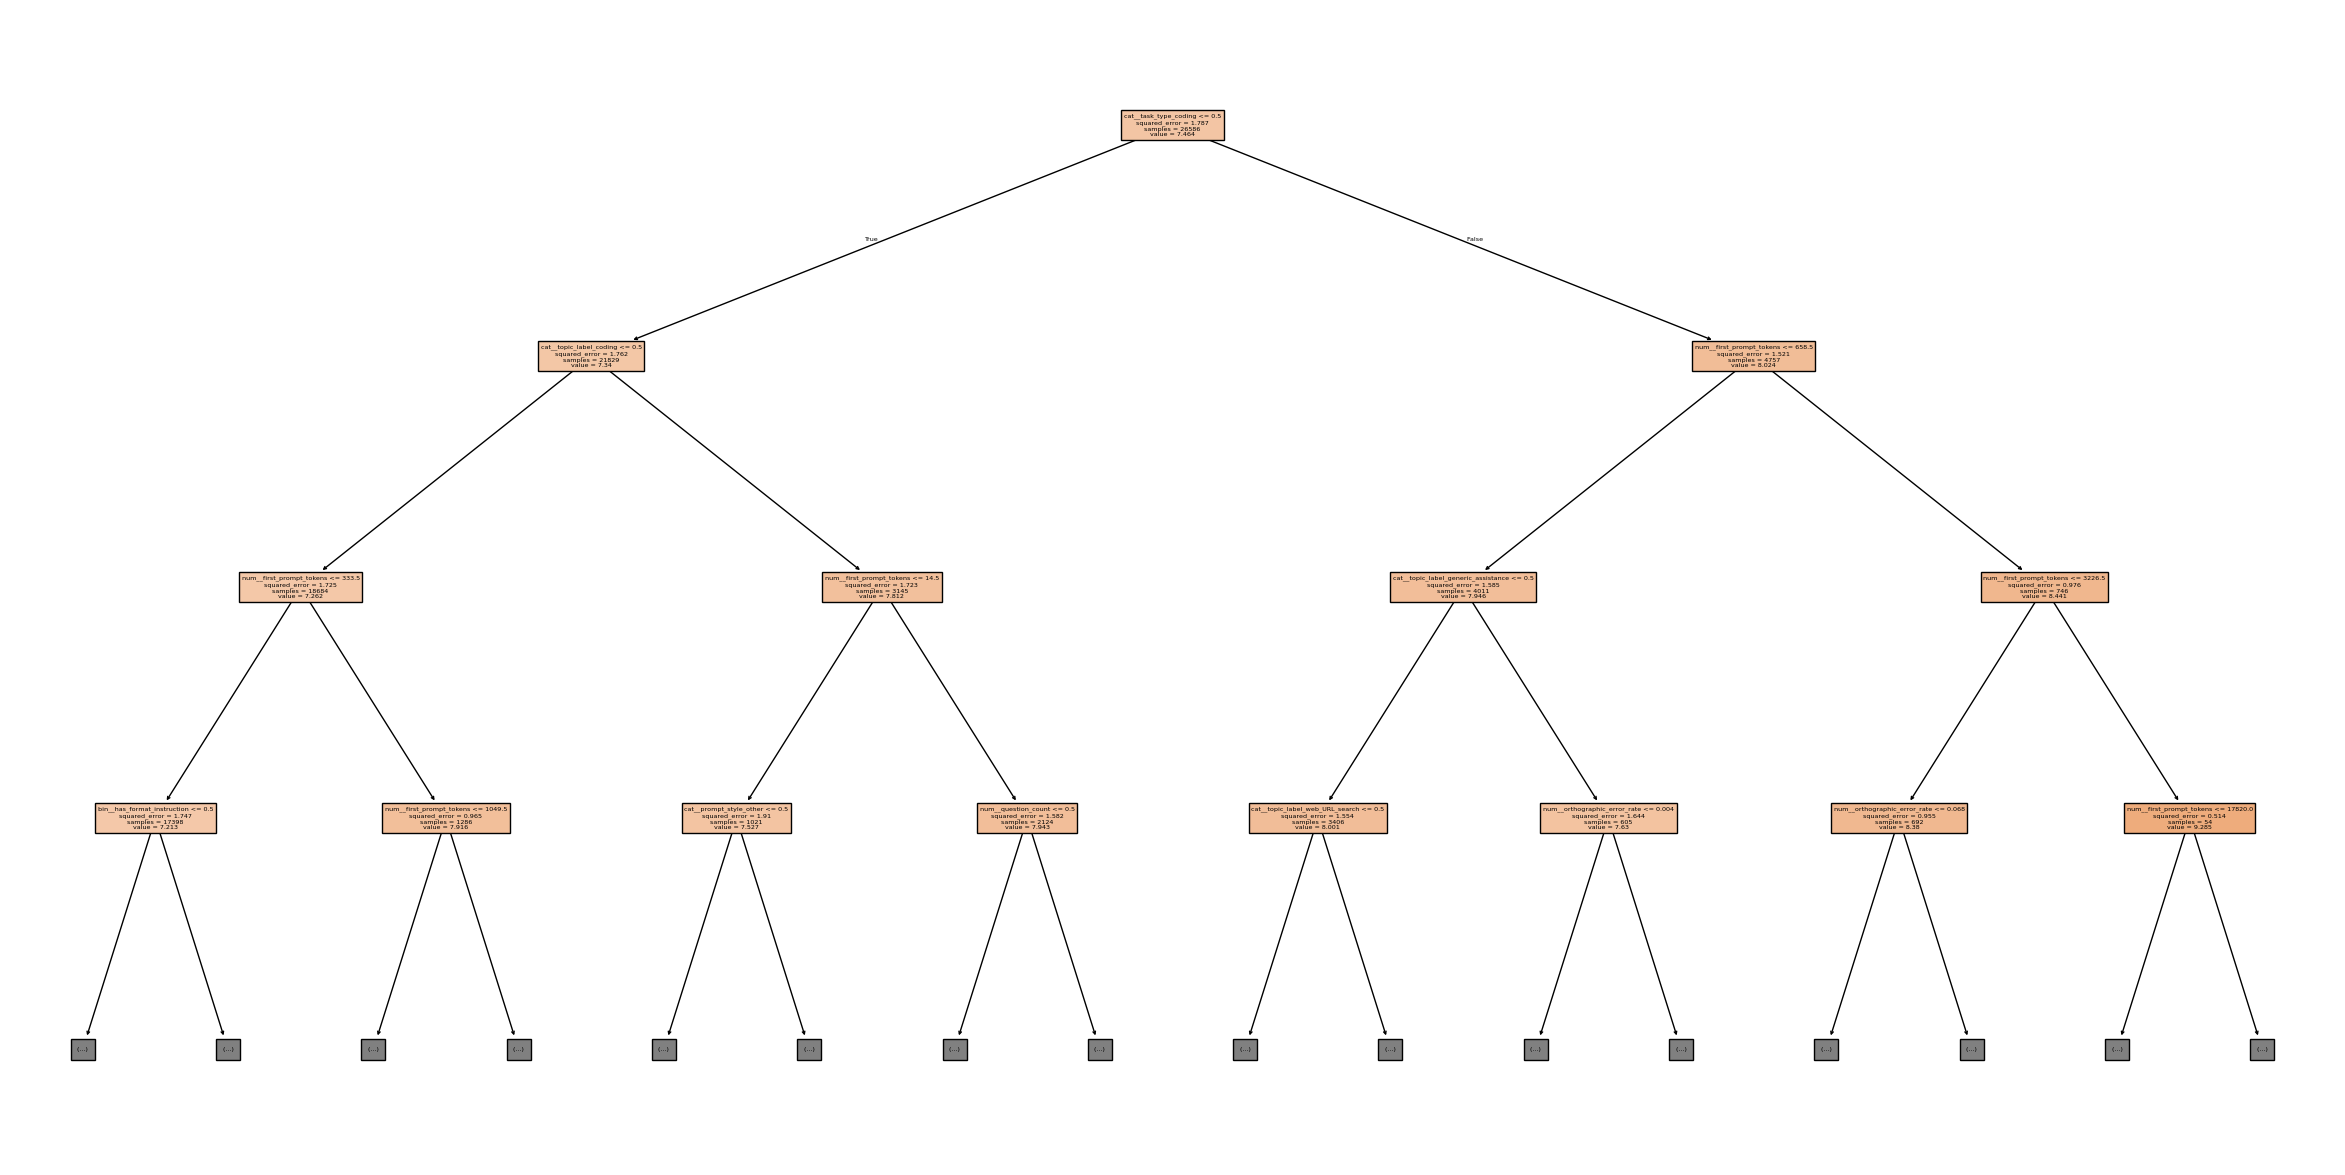

In [13]:
tree = model.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["no_follow_up", "follow_up"],
    filled=True,
    max_depth=3
)

plt.show()

In [14]:
df["target_cost"].describe()

count   52537.00
mean        7.45
std         1.33
min         3.14
25%         6.49
50%         7.40
75%         8.35
max        12.79
Name: target_cost, dtype: float64

# target_depth

In [15]:
# model
model_rfr_02 = RandomForestRegressor(random_state=42)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfr_02)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_depth"]
)

# predict test
target_test_depth_pred = pipeline.predict(df_test[features_cols])

# metrics
print("R2 Score:", r2_score(df_test["target_depth"], target_test_depth_pred))

R2 Score: 0.09146081840809606


In [9]:
# split datasets for efficiency

df_clusters = {
    24: df_train[df_train["macro_cluster"] == 24],   # Creative Generation & Instructional Writing**
    29: df_train[df_train["macro_cluster"] == 29],   # Educational / Societal / Informational Queries**
    30: df_train[df_train["macro_cluster"] == 30],   # Debate, Opinion & Exploratory Reasoning
    33: df_train[df_train["macro_cluster"] == 33],   # Systems, Backend & Low-Level Engineering**
    40: df_train[df_train["macro_cluster"] == 40],   # Conceptual Explanations & QA
    63: df_train[df_train["macro_cluster"] == 63],   # Applied Software Engineering / Production Coding
}

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# training for clusters

models = {}

for cluster_id, df_cluster in df_clusters.items():

    features_train = df_cluster[features_cols]
    target_train = df_cluster["target_cost"]

    df_test_cluster = df_test[df_test["macro_cluster"] == cluster_id]

    features_test = df_test_cluster[features_cols]
    target_test = df_test_cluster["target_cost"]

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=42))
    ])

    pipeline.fit(features_train, target_train)

    target_pred = pipeline.predict(features_test)

    r2 = r2_score(target_test, target_pred)

    models[cluster_id] = pipeline

    print(f"\nCluster {cluster_id}")
    print("R2 Score:", r2)

ValueError: A given column is not a column of the dataframe

In [18]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

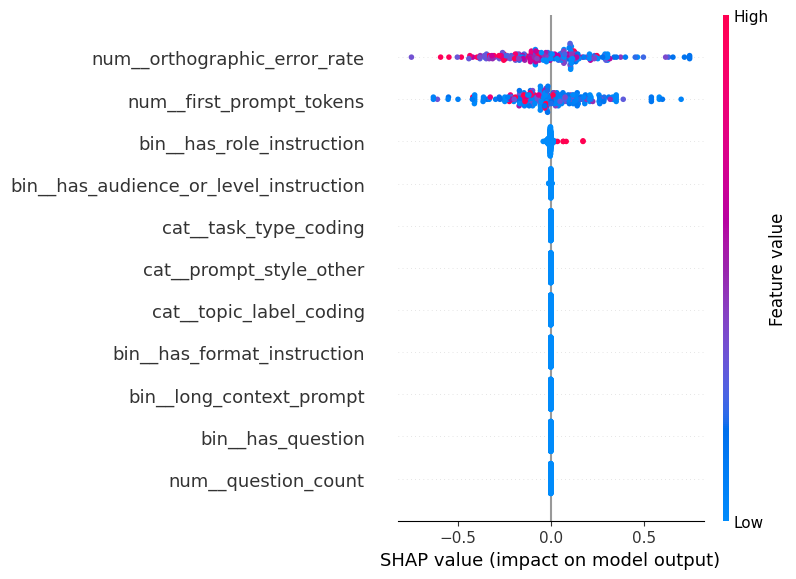

In [19]:
shap.summary_plot(
    shap_values,
    features_test_trans,
    feature_names=feature_names
)

In [20]:
# Top 5: orthographic_error_rate, first_prompt_tokens, has_role_instruction, has_audience_or_level_instruction, task_type_coding

In [5]:
# features selection
  
FEATURES_SELECTED_v03 = {
    'cat': [
        "task_type"                             #5   
        ],
    'num': [
        "first_prompt_tokens",                  #2        
        "orthographic_error_rate"              #1
        ],
    'bin': [
        "has_role_instruction",                 #3
        "has_audience_or_level_instruction"    #4
        ]
}

In [6]:
# model
model_rfr_03 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# preprocess

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v03['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v03['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v03['cat']),
    ],
    remainder="drop"
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_rfr_03)
])

features_cols = (
    FEATURES_SELECTED_v03['cat']
    + FEATURES_SELECTED_v03['num']
    + FEATURES_SELECTED_v03['bin']
)

features_train=df_train[features_cols]
target_train=df_train["target_cost"]

features_test = df_test[features_cols]
target_test = df_test["target_cost"]

# Pipeline trainiert
pipeline.fit(features_train, target_train)


# predict test
target_test_cost_pred = pipeline.predict(df_test[features_cols])

# metrics
print("R2 Score:", r2_score(df_test["target_cost"], target_test_cost_pred))

R2 Score: 0.09089287675210478


In [7]:
# transform
features_train = pipeline.named_steps["preprocess"].fit_transform(features_train)
features_test  = pipeline.named_steps["preprocess"].transform(features_test)

model = pipeline.named_steps["model"]

# explainer
explainer = shap.TreeExplainer(model)

# sample!
features_shap = shap.sample(features_test, 1000, random_state=42)

shap_values = explainer.shap_values(features_shap)

In [10]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

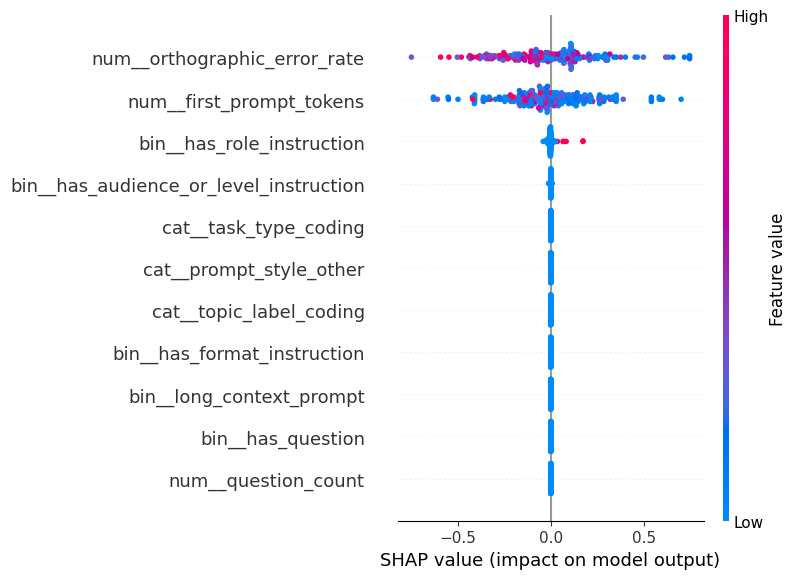

In [ ]:
shap.summary_plot(
    shap_values,
    features_test_trans,
    feature_names=feature_names
)

plt.show()

In [22]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_xgb_01 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_xgb_01)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_depth"]
)

# predict test
target_test_depth_pred = pipeline.predict(
    df_test[features_cols]
)

# metrics
print(
    "R2 Score:",
    r2_score(
        df_test["target_depth"],
        target_test_depth_pred
    )
)

R2 Score: 0.0668516669704663


In [29]:
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_xgb_02 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_xgb_02)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_cost"]
)

# predict test
target_test_cost_pred = pipeline.predict(
    df_test[features_cols]
)

# metrics
print(
    "R2 Score:",
    r2_score(
        df_test["target_cost"],
        target_test_cost_pred
    )
)

R2 Score: 0.13509027710968025


In [30]:
feature_names = pipeline.named_steps[
    "preprocess"
].get_feature_names_out()

import pandas as pd

global_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(global_importance.head(20))

                                   feature  importance
25           cat__prompt_style_instruction        0.10
18       cat__topic_label_creative_writing        0.06
24         cat__topic_label_web_URL_search        0.05
4   bin__has_audience_or_level_instruction        0.05
23     cat__topic_label_roleplay_jailbreak        0.05
13                 cat__task_type_roleplay        0.04
3                bin__has_role_instruction        0.04
22       cat__topic_label_noise_weakintent        0.04
10            cat__task_type_email_writing        0.04
21     cat__topic_label_hybrid_instruction        0.04
12       cat__task_type_general_assistance        0.04
26                 cat__prompt_style_other        0.03
16       cat__task_type_writing_generation        0.03
7                        bin__has_question        0.03
0                 num__first_prompt_tokens        0.03
15              cat__task_type_translation        0.03
20     cat__topic_label_generic_assistance        0.03
1         

In [15]:
##### depth #####

# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_xgb_02 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_xgb_02)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_depth"]
)

# predict test
target_test_depth_pred = pipeline.predict(
    df_test[features_cols]
)

# metrics
print(
    "R2 Score:",
    r2_score(
        df_test["target_depth"],
        target_test_depth_pred
    )
)

R2 Score: 0.0668516669704663


In [ ]:
# Modell holen
model = pipeline.named_steps["model"]

# Feature Namen holen
feature_names = pipeline.named_steps[
    "preprocess"
].get_feature_names_out()

# Importance DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# sortieren
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                                   feature  importance
25           cat__prompt_style_instruction        0.10
18       cat__topic_label_creative_writing        0.06
24         cat__topic_label_web_URL_search        0.05
4   bin__has_audience_or_level_instruction        0.05
23     cat__topic_label_roleplay_jailbreak        0.05
13                 cat__task_type_roleplay        0.04
3                bin__has_role_instruction        0.04
22       cat__topic_label_noise_weakintent        0.04
10            cat__task_type_email_writing        0.04
21     cat__topic_label_hybrid_instruction        0.04
12       cat__task_type_general_assistance        0.04
26                 cat__prompt_style_other        0.03
16       cat__task_type_writing_generation        0.03
7                        bin__has_question        0.03
0                 num__first_prompt_tokens        0.03
15              cat__task_type_translation        0.03
20     cat__topic_label_generic_assistance        0.03
1         

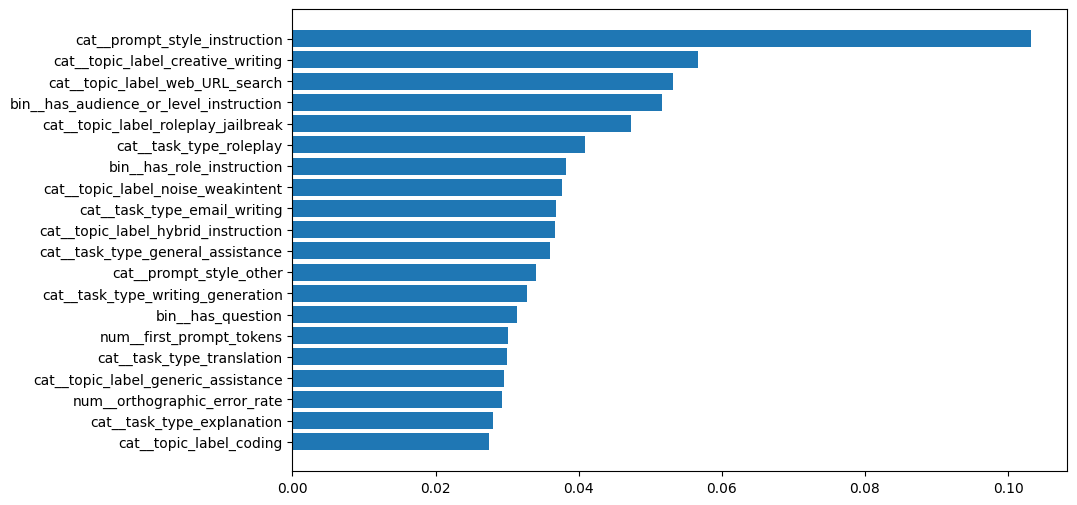

In [ ]:
top_features = importance_df.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.show()

In [25]:
model = pipeline.named_steps["model"]

importances = model.feature_importances_

In [27]:
# split datasets for efficiency

df_clusters = {
    24: df_train[df_train["macro_cluster"] == 24],   # Creative Generation & Instructional Writing**
    29: df_train[df_train["macro_cluster"] == 29],   # Educational / Societal / Informational Queries**
    30: df_train[df_train["macro_cluster"] == 30],   # Debate, Opinion & Exploratory Reasoning
    33: df_train[df_train["macro_cluster"] == 33],   # Systems, Backend & Low-Level Engineering**
    40: df_train[df_train["macro_cluster"] == 40],   # Conceptual Explanations & QA
    63: df_train[df_train["macro_cluster"] == 63],   # Applied Software Engineering / Production Coding
}

# training for clusters

models = {}

for cluster_id, df_cluster in df_clusters.items():

    features_train = df_cluster[features_cols]
    target_train = df_cluster["target_depth"]

    df_test_cluster = df_test[df_test["macro_cluster"] == cluster_id]

    features_test = df_test_cluster[features_cols]
    target_test = df_test_cluster["target_depth"]

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42))
    ])

    pipeline.fit(features_train, target_train)

    target_pred = pipeline.predict(features_test)

    r2 = r2_score(target_test, target_pred)

    models[cluster_id] = pipeline

    print(f"\nCluster {cluster_id}")
    print("R2 Score:", r2)


Cluster 24
R2 Score: -0.10003975188554981

Cluster 29
R2 Score: 0.010144753167709797

Cluster 30
R2 Score: -0.0014596871209457962

Cluster 33
R2 Score: -0.08038743187053043

Cluster 40
R2 Score: 0.08755595958399032

Cluster 63
R2 Score: 0.02205953837749519


In [28]:
# training for clusters

models = {}

for cluster_id, df_cluster in df_clusters.items():

    features_train = df_cluster[features_cols]
    target_train = df_cluster["target_cost"]

    df_test_cluster = df_test[df_test["macro_cluster"] == cluster_id]

    features_test = df_test_cluster[features_cols]
    target_test = df_test_cluster["target_cost"]

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42))
    ])

    pipeline.fit(features_train, target_train)

    target_pred = pipeline.predict(features_test)

    r2 = r2_score(target_test, target_pred)

    models[cluster_id] = pipeline

    print(f"\nCluster {cluster_id}")
    print("R2 Score:", r2)


Cluster 24
R2 Score: -0.10967221145168127

Cluster 29
R2 Score: 0.02627659299365781

Cluster 30
R2 Score: -0.012212434255087778

Cluster 33
R2 Score: -0.05516623682929134

Cluster 40
R2 Score: 0.04956589298228309

Cluster 63
R2 Score: 0.006582224484268706


In [33]:
# training for clusters

models = {}

for cluster_id, df_cluster in df_clusters.items():

    features_train = df_cluster[features_cols]
    target_train = df_cluster["target_cost"]

    df_test_cluster = df_test[df_test["macro_cluster"] == cluster_id]

    features_test = df_test_cluster[features_cols]
    target_test = df_test_cluster["target_cost"]

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42))
                ])

    pipeline.fit(features_train, target_train)

    target_pred = pipeline.predict(features_test)

    r2 = r2_score(target_test, target_pred)

    models[cluster_id] = pipeline

    print(f"\nCluster {cluster_id}")
    print("R2 Score:", r2)


Cluster 24
R2 Score: -0.10967221145168127

Cluster 29
R2 Score: 0.02627659299365781

Cluster 30
R2 Score: -0.012212434255087778

Cluster 33
R2 Score: -0.05516623682929134

Cluster 40
R2 Score: 0.04956589298228309

Cluster 63
R2 Score: 0.006582224484268706


In [35]:
df[["target_cost", "target_depth", "target_success"]].corr()

,target_cost,target_depth,target_success
target_cost,1.00,0.82,-0.60
target_depth,0.82,1.00,-0.68
target_success,-0.60,-0.68,1.00


In [ ]:
df["effort"] = PCA(n_components=1).fit_transform(df[["target_cost", "target_depth"]])

efficiency = success / effort

In [5]:
pd.crosstab(df["task_type"], df["topic_label"])

topic_label,coding,creative_writing,educational_explanation,generic_assistance,hybrid_instruction,noise_weakintent,roleplay_jailbreak,web_URL_search
task_type,,,,,,,,
brainstorming,126,9,10,1567,165,29,121,39
coding,5038,472,159,1859,679,123,147,745
email_writing,64,194,14,642,42,51,10,320
explanation,549,167,1707,1974,228,129,197,184
general_assistance,4341,239,187,12888,2124,853,468,1050
roleplay,75,4,4,722,95,29,64,17
summarization,39,199,11,622,37,28,29,191
translation,76,368,9,359,27,27,9,31
writing_generation,918,4636,15,2582,918,171,78,237


In [7]:
df["code"] = (
    (df["task_type"] == "coding") |
    (df["topic_label"] == "coding")
)

In [8]:
df["code"].value_counts()

code
False    37127
True     15410
Name: count, dtype: int64

In [ ]:
df_non_code=df[df["code"]==False]
len(df_non_code)

In [14]:
##### depth #####

# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_xgb_02 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_xgb_02)
])

# fit model
pipeline.fit(
    df_non_code[features_cols],
    df_non_code["target_depth"]
)

# predict test
target_test_depth_pred = pipeline.predict(
    df_test[features_cols]
)

# metrics
print(
    "R2 Score:",
    r2_score(
        df_test["target_depth"],
        target_test_depth_pred
    )
)

R2 Score: 0.11448687996735318


In [16]:
# Modell holen
model = pipeline.named_steps["model"]

# Feature Namen holen
feature_names = pipeline.named_steps[
    "preprocess"
].get_feature_names_out()

# Importance DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# sortieren
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                                   feature  importance
25           cat__prompt_style_instruction        0.10
18       cat__topic_label_creative_writing        0.06
24         cat__topic_label_web_URL_search        0.05
4   bin__has_audience_or_level_instruction        0.05
23     cat__topic_label_roleplay_jailbreak        0.05
13                 cat__task_type_roleplay        0.04
3                bin__has_role_instruction        0.04
22       cat__topic_label_noise_weakintent        0.04
10            cat__task_type_email_writing        0.04
21     cat__topic_label_hybrid_instruction        0.04
12       cat__task_type_general_assistance        0.04
26                 cat__prompt_style_other        0.03
16       cat__task_type_writing_generation        0.03
7                        bin__has_question        0.03
0                 num__first_prompt_tokens        0.03
15              cat__task_type_translation        0.03
20     cat__topic_label_generic_assistance        0.03
1         

In [17]:
##### depth #####

# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_xgb_02 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model_xgb_02)
])

# fit model
pipeline.fit(
    df_non_code[features_cols],
    df_non_code["target_cost"]
)

# predict test
target_test_cost_pred = pipeline.predict(
    df_test[features_cols]
)

# metrics
print(
    "R2 Score:",
    r2_score(
        df_test["target_cost"],
        target_test_cost_pred
    )
)

R2 Score: 0.12421811813828498


In [18]:
# Modell holen
model = pipeline.named_steps["model"]

# Feature Namen holen
feature_names = pipeline.named_steps[
    "preprocess"
].get_feature_names_out()

# Importance DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# sortieren
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                                     feature  importance
4     bin__has_audience_or_level_instruction        0.16
6                   bin__long_context_prompt        0.08
5                bin__has_format_instruction        0.07
20         cat__topic_label_noise_weakintent        0.04
24                   cat__prompt_style_other        0.04
0                   num__first_prompt_tokens        0.04
9               cat__task_type_email_writing        0.04
16         cat__topic_label_creative_writing        0.04
23             cat__prompt_style_instruction        0.04
19       cat__topic_label_hybrid_instruction        0.03
17  cat__topic_label_educational_explanation        0.03
11         cat__task_type_general_assistance        0.03
1               num__orthographic_error_rate        0.03
10                cat__task_type_explanation        0.03
15         cat__task_type_writing_generation        0.03
3                  bin__has_role_instruction        0.03
22           cat__topic_label_w

In [20]:
### shape

features = pipeline.named_steps["preprocess"].transform(
    df_non_code[features_cols]
)

model = pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)

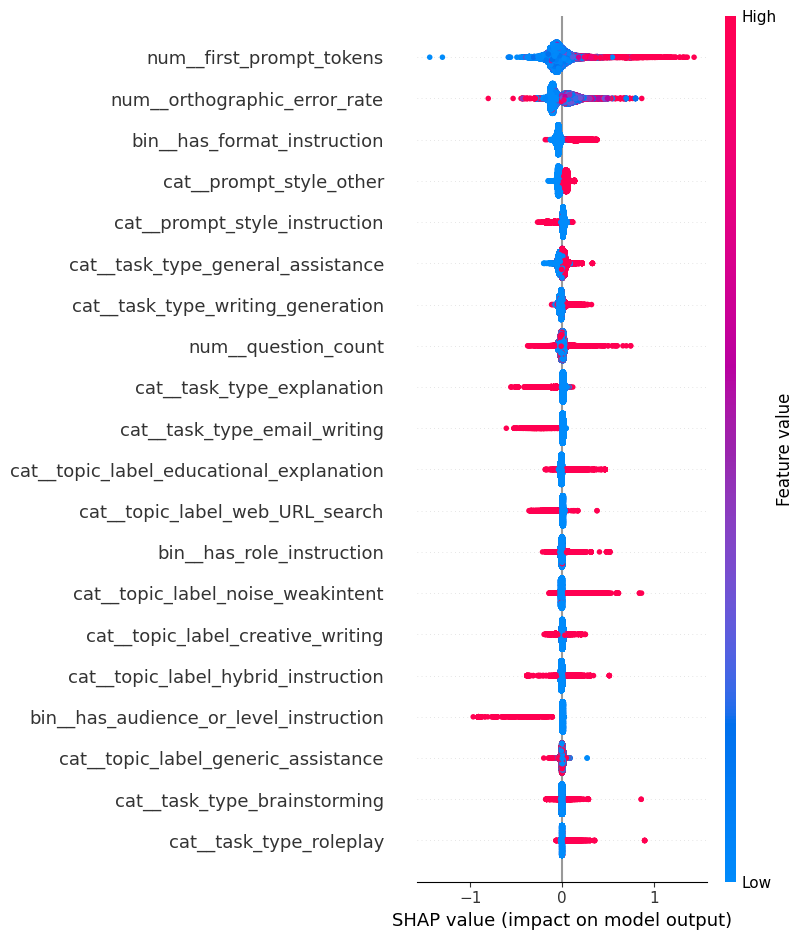

In [21]:
shap.summary_plot(
    shap_values,
    features,
    feature_names=pipeline.named_steps["preprocess"].get_feature_names_out()
)

In [23]:
shap.dependence_plot(
    "num__first_prompt_tokens",
    shap_values,
    features_transformed,
    feature_names=feature_names
)

NameError: name 'features_transformed' is not defined